In [23]:
# CELDA 1
# =========================
# EC_3 - Clasificación de riesgo crediticio
# Modelos: Ridge, Lasso, Bagging, Random Forest
# Grupo 12: Luis Puicón y Erick Díaz
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [2]:
# CELDA 2
# =========================
# (GRÁFICOS) Funciones auxiliares para evaluación y visualización
# =========================
import matplotlib.pyplot as plt

# (Opcional) seaborn si está disponible
try:
    import seaborn as sns
    sns.set_style("whitegrid")
except Exception:
    sns = None

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.inspection import permutation_importance

def _get_feature_names(preprocess):
    """Nombres de features tras ColumnTransformer (num + onehot)."""
    try:
        return preprocess.get_feature_names_out()
    except Exception:
        feature_names = []
        for name, trans, cols in preprocess.transformers_:
            if name == "remainder":
                continue
            if hasattr(trans, "get_feature_names_out"):
                feature_names.extend(list(trans.get_feature_names_out(cols)))
            else:
                feature_names.extend(list(cols))
        return np.array(feature_names, dtype=object)

def plot_cv_score_curve(gs, param_name, x_transform=None, x_label=None, title=None):
    """
    Grafica mean_test_score vs valor del hiperparámetro.
    Si x_transform existe (p.ej. lambda=1/C), transforma el eje x.
    """
    results = pd.DataFrame(gs.cv_results_)
    xs = results[f"param_{param_name}"].astype(float).values
    ys = results["mean_test_score"].values
    yerr = results["std_test_score"].values

    if x_transform is not None:
        xs_plot = np.array([x_transform(x) for x in xs], dtype=float)
    else:
        xs_plot = xs

    order = np.argsort(xs_plot)
    xs_plot, ys, yerr = xs_plot[order], ys[order], yerr[order]

    plt.figure(figsize=(8,4))
    plt.plot(xs_plot, ys, marker="o")
    plt.fill_between(xs_plot, ys - yerr, ys + yerr, alpha=0.2)
    plt.xlabel(x_label if x_label else param_name)
    plt.ylabel("Score CV")
    plt.title(title if title else f"CV score vs {param_name}")
    plt.tight_layout()
    plt.show()

def plot_roc_curve_from_estimator(estimator, X, y, title="ROC"):
    proba = estimator.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return roc_auc

def plot_pr_curve_from_estimator(estimator, X, y, title="Precision-Recall"):
    proba = estimator.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y, proba)
    ap = average_precision_score(y, proba)

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return ap

def plot_confusion_matrix_from_estimator(estimator, X, y, threshold=0.5, title="Matriz de confusión"):
    proba = estimator.predict_proba(X)[:, 1]
    yhat = (proba >= threshold).astype(int)
    cm = confusion_matrix(y, yhat)

    plt.figure(figsize=(5,4))
    if sns is not None:
        sns.heatmap(cm, annot=True, fmt="d", cbar=False)
    else:
        plt.imshow(cm)
        plt.colorbar()
        for (i, j), val in np.ndenumerate(cm):
            plt.text(j, i, str(val), ha='center', va='center')
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.title(title + f" (thr={threshold})")
    plt.tight_layout()
    plt.show()

    print(classification_report(y, yhat, target_names=["Low Risk(0)", "High Risk(1)"]))

def plot_top_coefficients(logit_estimator, preprocess, top=15, title="Top coeficientes (|beta|)"):
    """
    logit_estimator debe ser un LogisticRegression ya entrenado (dentro de Pipeline).
    """
    feat_names = _get_feature_names(preprocess)
    coefs = logit_estimator.coef_.ravel()
    s = pd.Series(coefs, index=feat_names)
    s_abs = s.abs().sort_values(ascending=False).head(top)[::-1]

    plt.figure(figsize=(8,5))
    plt.barh(s_abs.index.astype(str), s_abs.values)
    plt.title(title)
    plt.xlabel("|coef|")
    plt.tight_layout()
    plt.show()

def plot_feature_importance_rf(rf_estimator, preprocess, top=20, title="Feature importance (RF)"):
    feat_names = _get_feature_names(preprocess)
    importances = rf_estimator.feature_importances_
    s = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(top)[::-1]

    plt.figure(figsize=(8,6))
    plt.barh(s.index.astype(str), s.values)
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

def plot_permutation_importance(estimator, X, y, preprocess, top=20, title="Permutation importance (test)"):
    feat_names = _get_feature_names(preprocess)
    # OJO: X aquí debe ser ya transformado si pasas estimator sin pipeline.
    # Para evitar líos, usamos estimator = pipeline y X original.
    r = permutation_importance(estimator, X, y, n_repeats=10, random_state=42, scoring="roc_auc")
    s = pd.Series(r.importances_mean, index=feat_names).sort_values(ascending=False).head(top)[::-1]

    plt.figure(figsize=(8,6))
    plt.barh(s.index.astype(str), s.values)
    plt.title(title)
    plt.xlabel("Mean importance (AUC drop)")
    plt.tight_layout()
    plt.show()

In [3]:
# CELDA 3
# =========================
# Cargar datos
# =========================
path = "/content/credit_data.xlsx"  # ajusta si tu ruta cambia
df = pd.read_excel(path)

print("Shape:", df.shape)
display(df.head())

print("\nColumnas:")
print(df.columns.tolist())

Shape: (5000, 31)


,annual_income,employment_status,employment_length,additional_income,dti_ratio,credit_score,payment_history,credit_history_length,credit_accounts,credit_utilization,...,education,residential_status,time_at_address,marital_status,loan_purpose,loan_amount,collateral,relationship_length,industry,risk_category
0,84770.247656,Employed,2.115363,0.000000,0.467777,850.000000,686.505837,514.529988,343.514675,-429.080375,...,Bachelor,Own,4.365976,Married,Personal,50744.991013,Yes,0.803040,Finance,Low Risk
1,54350.820508,Employed,2.894678,18574.827750,0.580839,686.926572,549.657890,411.881323,274.600018,-342.795000,...,Bachelor,Own,4.324678,Single,Personal,38409.453178,No,2.142392,Other,High Risk
2,94219.455826,Employed,3.575867,0.000000,0.287052,693.910853,555.560382,415.604857,278.367881,-347.582645,...,Bachelor,Own,3.728989,Married,Auto,13528.662736,Yes,3.689854,Other,Low Risk
3,173880.037277,Employed,10.387669,3839.831236,0.371362,730.917596,584.759574,438.815219,292.124634,-366.436084,...,Bachelor,Rent,7.684848,Single,Home,44702.833269,Yes,9.780368,Finance,Low Risk
4,50822.407950,Employed,1.767646,713.893021,0.525622,748.846445,599.082537,448.952941,299.519949,-375.150236,...,Master,Rent,16.350986,Married,Home,60421.765088,Yes,3.175508,Finance,High Risk



Columnas:
['annual_income', 'employment_status', 'employment_length', 'additional_income', 'dti_ratio', 'credit_score', 'payment_history', 'credit_history_length', 'credit_accounts', 'credit_utilization', 'recent_inquiries', 'bankruptcies', 'collections', 'credit_mix', 'total_assets', 'bank_balance', 'investments', 'real_estate', 'debt_obligations', 'monthly_expenses', 'age', 'education', 'residential_status', 'time_at_address', 'marital_status', 'loan_purpose', 'loan_amount', 'collateral', 'relationship_length', 'industry', 'risk_category']


In [4]:
# CELDA 4
# =========================
# Target y preparación X/y
# =========================
target = "risk_category"

print(df[target].value_counts(dropna=False))

df = df.copy()
df[target] = df[target].map({"Low Risk": 0, "High Risk": 1})

if df[target].isna().any():
    raise ValueError("Hay valores en risk_category que no son 'Low Risk'/'High Risk'. Revisa el mapeo.")

X = df.drop(columns=[target])
y = df[target].astype(int)

print("\nBalance y (0=Low, 1=High):")
print(y.value_counts())
print(y.value_counts(normalize=True))

risk_category
Low Risk     2500
High Risk    2500
Name: count, dtype: int64

Balance y (0=Low, 1=High):
risk_category
0    2500
1    2500
Name: count, dtype: int64
risk_category
0    0.5
1    0.5
Name: proportion, dtype: float64


In [5]:
# CELDA 5
# =========================
# Split + Preprocess + CV
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Numéricas:", len(num_cols), num_cols[:10])
print("Categóricas:", len(cat_cols), cat_cols)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ]
)

Train: (4000, 30)  Test: (1000, 30)
Numéricas: 23 ['annual_income', 'employment_length', 'additional_income', 'dti_ratio', 'credit_score', 'payment_history', 'credit_history_length', 'credit_accounts', 'credit_utilization', 'recent_inquiries']
Categóricas: 7 ['employment_status', 'education', 'residential_status', 'marital_status', 'loan_purpose', 'collateral', 'industry']


In [6]:
# CELDA 6
# =========================
# RIDGE (Logit L2) - GridSearch
# =========================
lambdas = np.linspace(0.01, 10, 50)
C_grid = 1 / lambdas

ridge = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=5000,
    random_state=RANDOM_STATE
)

ridge_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", ridge)
])

ridge_gs = GridSearchCV(
    ridge_pipe,
    param_grid={"model__C": C_grid},
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

ridge_gs.fit(X_train, y_train)

print("=== RIDGE (Logit L2) ===")
print("Mejor lambda:", 1 / ridge_gs.best_params_["model__C"])
print("Mejor C:", ridge_gs.best_params_["model__C"])
print("Mejor AUC CV:", ridge_gs.best_score_)

=== RIDGE (Logit L2) ===
Mejor lambda: 0.01
Mejor C: 100.0
Mejor AUC CV: 0.9998125


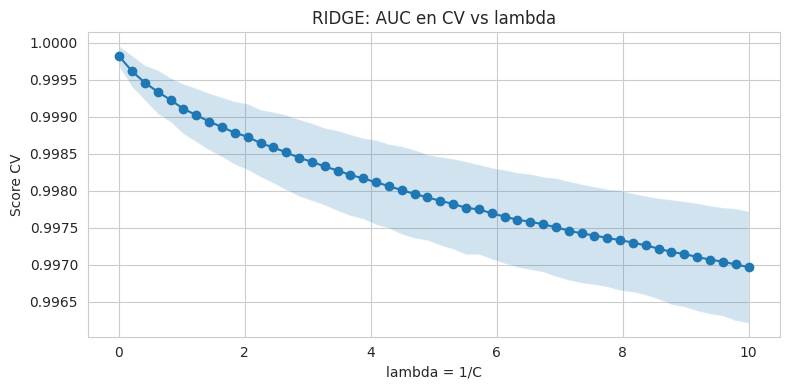

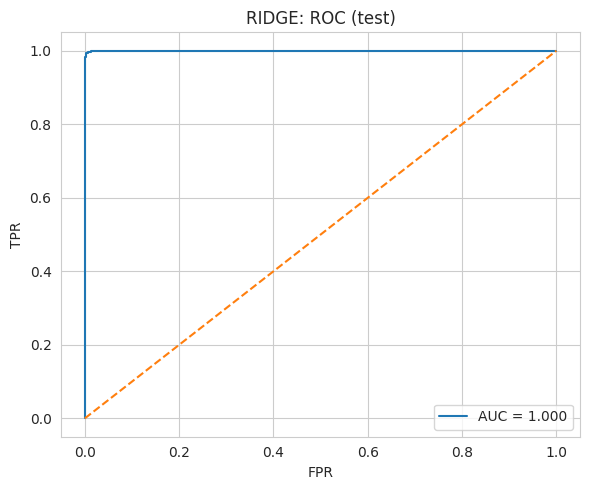

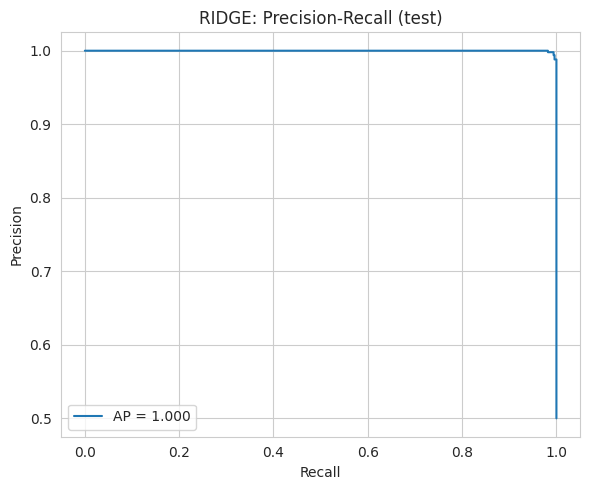

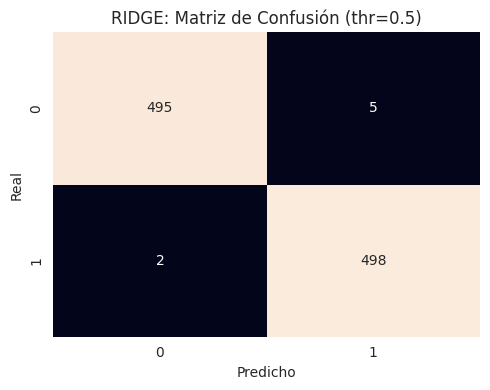

              precision    recall  f1-score   support

 Low Risk(0)       1.00      0.99      0.99       500
High Risk(1)       0.99      1.00      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



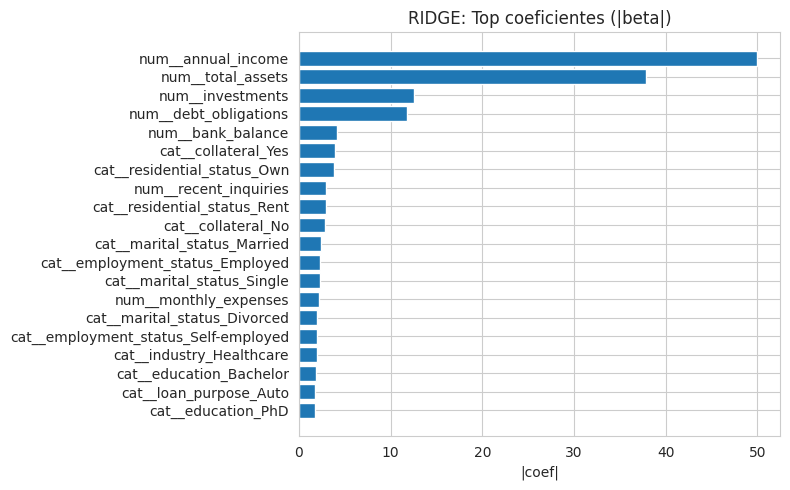

In [7]:
# CELDA 7
# =========================
# (GRÁFICOS) RIDGE
# =========================
ridge_best = ridge_gs.best_estimator_

plot_cv_score_curve(
    ridge_gs,
    param_name="model__C",
    x_transform=lambda C: 1/float(C),
    x_label="lambda = 1/C",
    title="RIDGE: AUC en CV vs lambda"
)

_ = plot_roc_curve_from_estimator(ridge_best, X_test, y_test, title="RIDGE: ROC (test)")
_ = plot_pr_curve_from_estimator(ridge_best, X_test, y_test, title="RIDGE: Precision-Recall (test)")
plot_confusion_matrix_from_estimator(ridge_best, X_test, y_test, threshold=0.5, title="RIDGE: Matriz de Confusión")

prep_ridge = ridge_best.named_steps["prep"]
model_ridge = ridge_best.named_steps["model"]
plot_top_coefficients(model_ridge, prep_ridge, top=20, title="RIDGE: Top coeficientes (|beta|)")

In [8]:
# CELDA 8
# =========================
# LASSO (Logit L1) - GridSearch
# =========================
lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",   # estable y rápido para L1 (mejor que saga si no necesitas multinomial)
    max_iter=5000,
    random_state=RANDOM_STATE
)

lasso_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", lasso)
])

lasso_gs = GridSearchCV(
    lasso_pipe,
    param_grid={"model__C": C_grid},
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

lasso_gs.fit(X_train, y_train)

print("=== LASSO (Logit L1) ===")
print("Mejor lambda:", 1 / lasso_gs.best_params_["model__C"])
print("Mejor C:", lasso_gs.best_params_["model__C"])
print("Mejor AUC CV:", lasso_gs.best_score_)

=== LASSO (Logit L1) ===
Mejor lambda: 0.01
Mejor C: 100.0
Mejor AUC CV: 0.9998837500000001


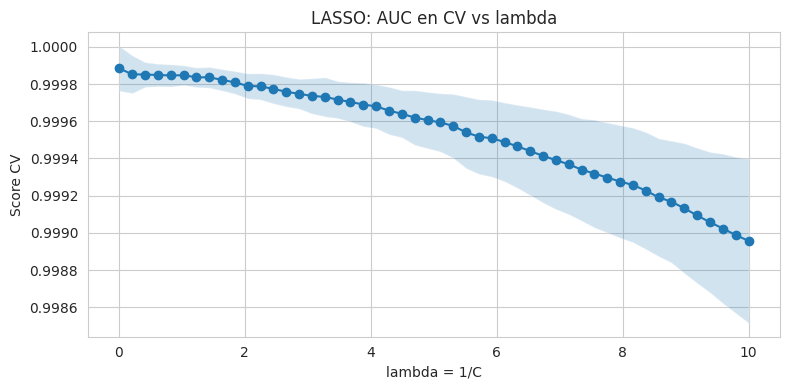

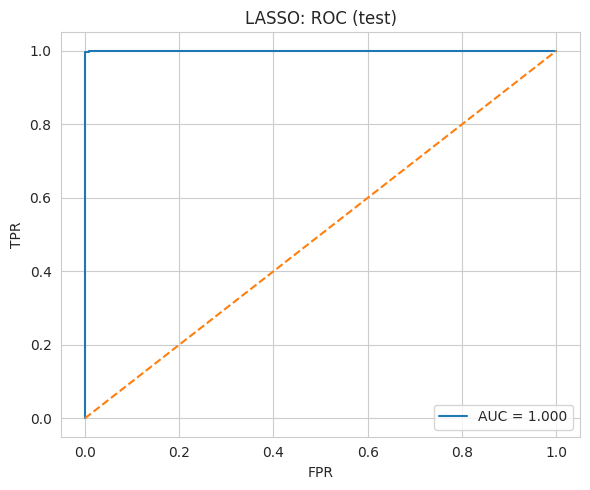

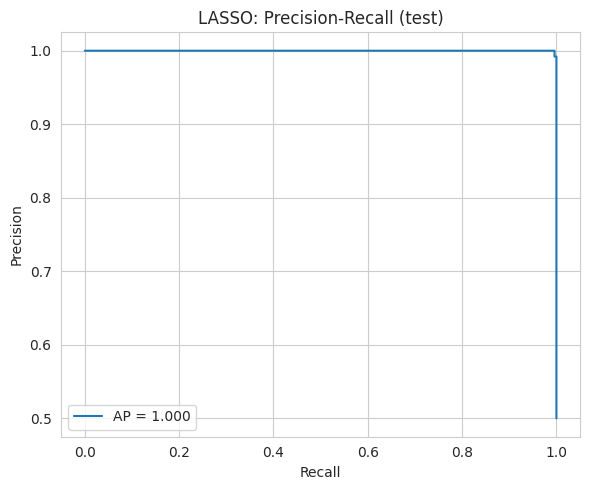

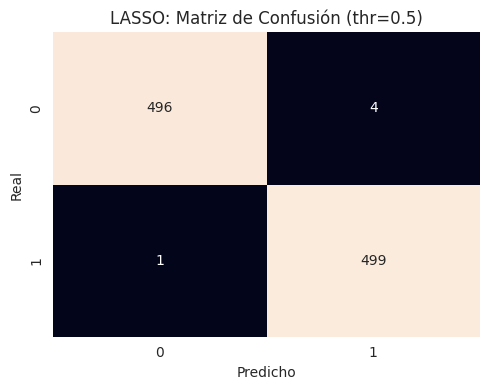

              precision    recall  f1-score   support

 Low Risk(0)       1.00      0.99      0.99       500
High Risk(1)       0.99      1.00      1.00       500

    accuracy                           0.99      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      0.99      0.99      1000



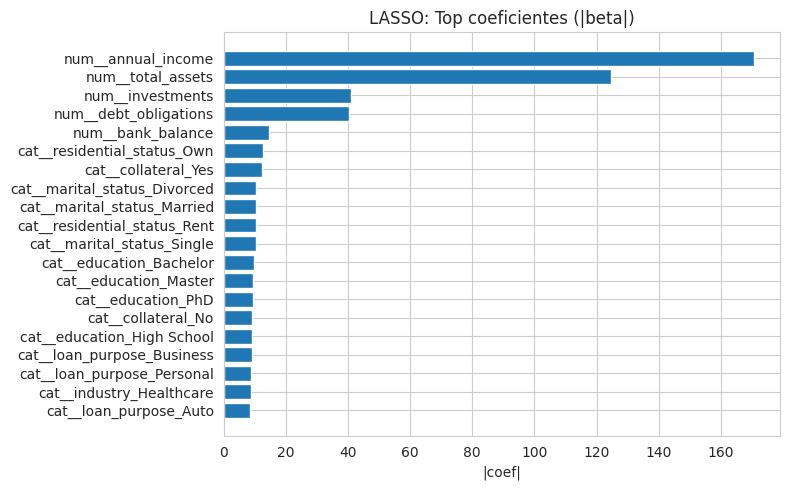

Coeficientes en 0: 0 / 47 (0.0%)


In [9]:
# CELDA 9
# =========================
# (GRÁFICOS) LASSO
# =========================
lasso_best = lasso_gs.best_estimator_

plot_cv_score_curve(
    lasso_gs,
    param_name="model__C",
    x_transform=lambda C: 1/float(C),
    x_label="lambda = 1/C",
    title="LASSO: AUC en CV vs lambda"
)

_ = plot_roc_curve_from_estimator(lasso_best, X_test, y_test, title="LASSO: ROC (test)")
_ = plot_pr_curve_from_estimator(lasso_best, X_test, y_test, title="LASSO: Precision-Recall (test)")
plot_confusion_matrix_from_estimator(lasso_best, X_test, y_test, threshold=0.5, title="LASSO: Matriz de Confusión")

prep_lasso = lasso_best.named_steps["prep"]
model_lasso = lasso_best.named_steps["model"]
plot_top_coefficients(model_lasso, prep_lasso, top=20, title="LASSO: Top coeficientes (|beta|)")

# Extra "tipo clase": ¿cuántos coeficientes quedaron exactamente en 0?
feat_names_lasso = _get_feature_names(prep_lasso)
coefs_lasso = model_lasso.coef_.ravel()
n_zero = np.sum(np.isclose(coefs_lasso, 0.0))
print(f"Coeficientes en 0: {n_zero} / {len(coefs_lasso)} ({100*n_zero/len(coefs_lasso):.1f}%)")

In [10]:
# CELDA 10
# =========================
# Bagging (DecisionTree base) - GridSearch
# =========================
n_estimators_grid = list(range(10, 101, 10))                   # 10..100
min_samples_split_grid = np.linspace(5, 20, 5, dtype=int).tolist()  # 5 valores

base_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

bag = BaggingClassifier(
    estimator=base_tree,
    random_state=RANDOM_STATE
)

bag_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", bag)
])

bag_gs = GridSearchCV(
    bag_pipe,
    param_grid={
        "model__n_estimators": n_estimators_grid,
        "model__estimator__min_samples_split": min_samples_split_grid
    },
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

bag_gs.fit(X_train, y_train)

print("=== BAGGING ===")
print("Mejor params:", bag_gs.best_params_)
print("Mejor AUC CV:", bag_gs.best_score_)

=== BAGGING ===
Mejor params: {'model__estimator__min_samples_split': 12, 'model__n_estimators': 70}
Mejor AUC CV: 0.99603875


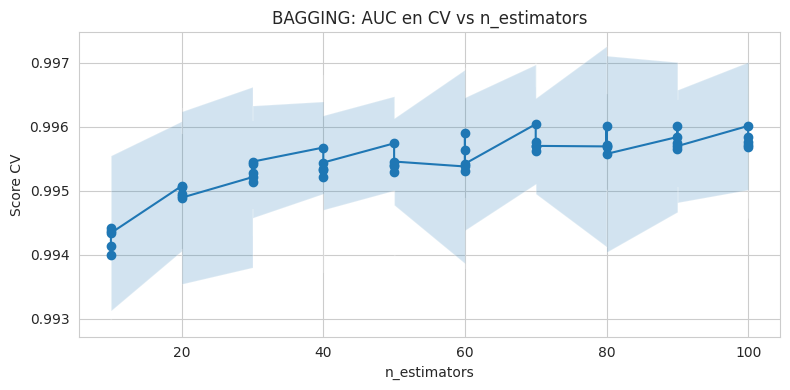

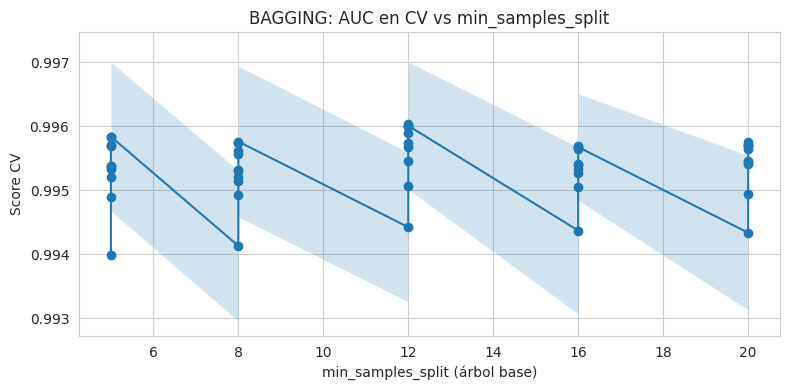

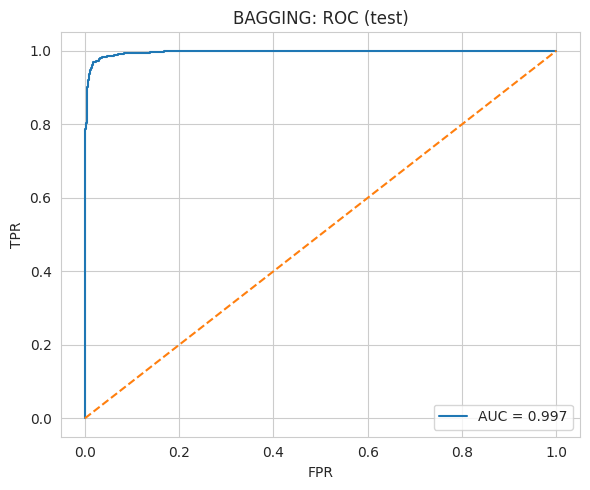

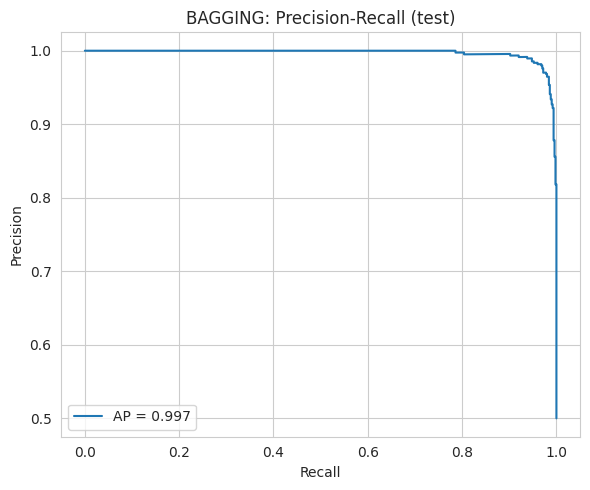

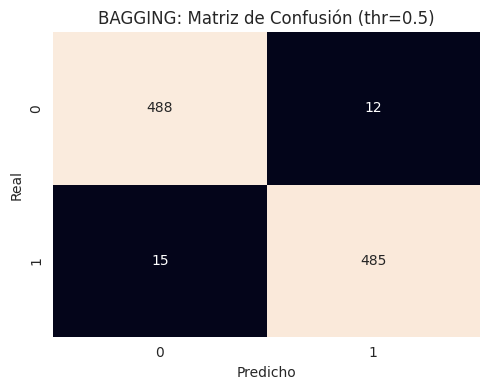

              precision    recall  f1-score   support

 Low Risk(0)       0.97      0.98      0.97       500
High Risk(1)       0.98      0.97      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



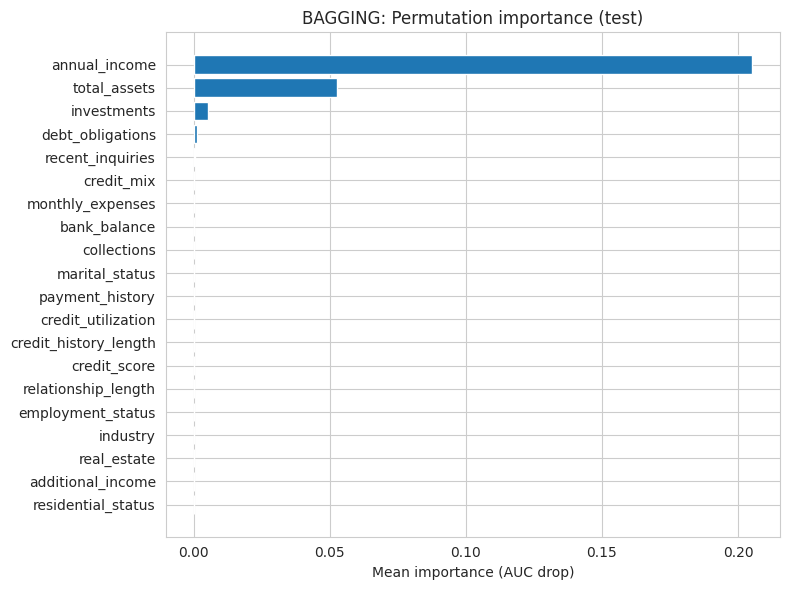

In [22]:
# CELDA 11
# =========================
# (GRÁFICOS) Bagging
# =========================
bag_best = bag_gs.best_estimator_

plot_cv_score_curve(
    bag_gs,
    param_name="model__n_estimators",
    x_label="n_estimators",
    title="BAGGING: AUC en CV vs n_estimators"
)

# min_samples_split del árbol base
plot_cv_score_curve(
    bag_gs,
    param_name="model__estimator__min_samples_split",
    x_label="min_samples_split (árbol base)",
    title="BAGGING: AUC en CV vs min_samples_split"
)

_ = plot_roc_curve_from_estimator(bag_best, X_test, y_test, title="BAGGING: ROC (test)")
_ = plot_pr_curve_from_estimator(bag_best, X_test, y_test, title="BAGGING: Precision-Recall (test)")
plot_confusion_matrix_from_estimator(bag_best, X_test, y_test, threshold=0.5, title="BAGGING: Matriz de Confusión")

# Extra "tipo clase": permutation importance en test (sobre el pipeline completo)
# Para feature names, tomamos los del preprocess ya fiteado dentro del pipeline
prep_bag = bag_best.named_steps["prep"]
plot_permutation_importance(bag_best, X_test, y_test, prep_bag, top=20, title="BAGGING: Permutation importance (test)")

In [12]:
# CELDA 12
# =========================
# Random Forest - GridSearch
# =========================
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", rf)
])

rf_param_grid = {
    "model__n_estimators": n_estimators_grid,
    "model__min_samples_split": min_samples_split_grid
}

rf_gs = GridSearchCV(
    rf_pipe,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

rf_gs.fit(X_train, y_train)

print("=== RANDOM FOREST ===")
print("Mejor params:", rf_gs.best_params_)
print("Mejor AUC CV:", rf_gs.best_score_)

=== RANDOM FOREST ===
Mejor params: {'model__min_samples_split': 5, 'model__n_estimators': 100}
Mejor AUC CV: 0.9966125


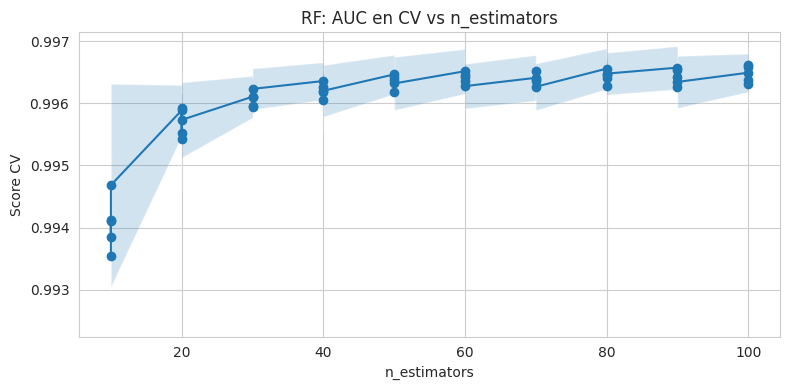

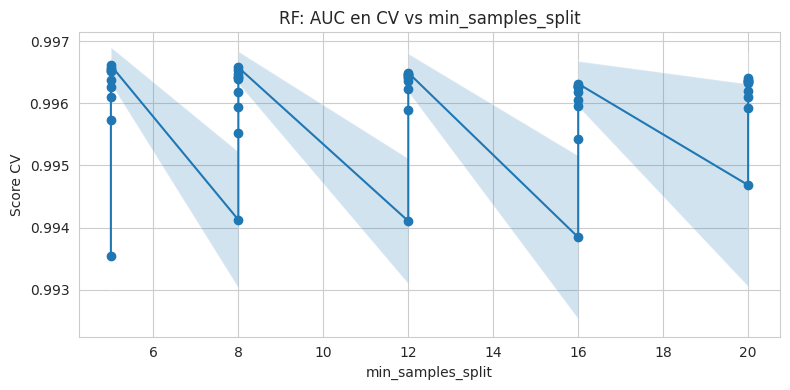

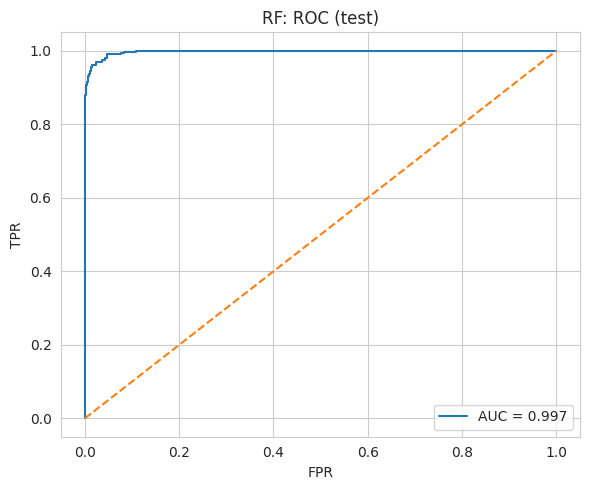

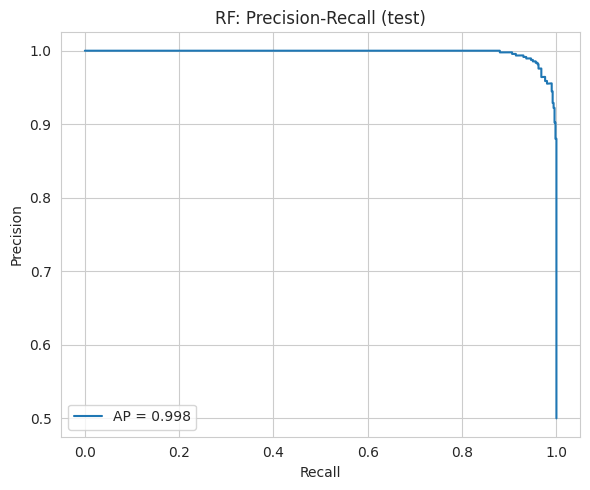

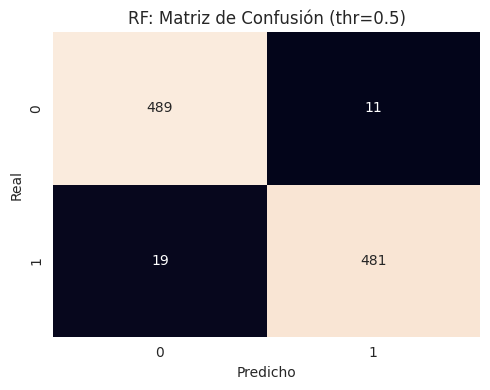

              precision    recall  f1-score   support

 Low Risk(0)       0.96      0.98      0.97       500
High Risk(1)       0.98      0.96      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



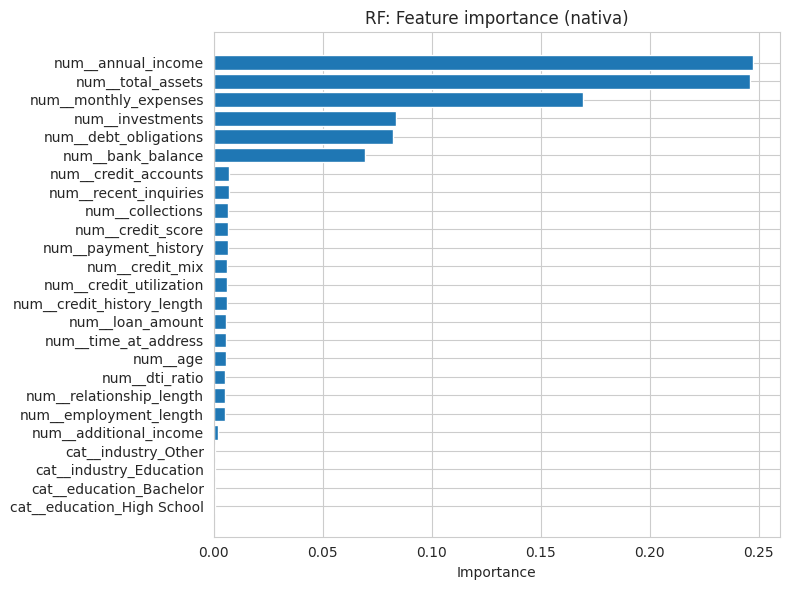

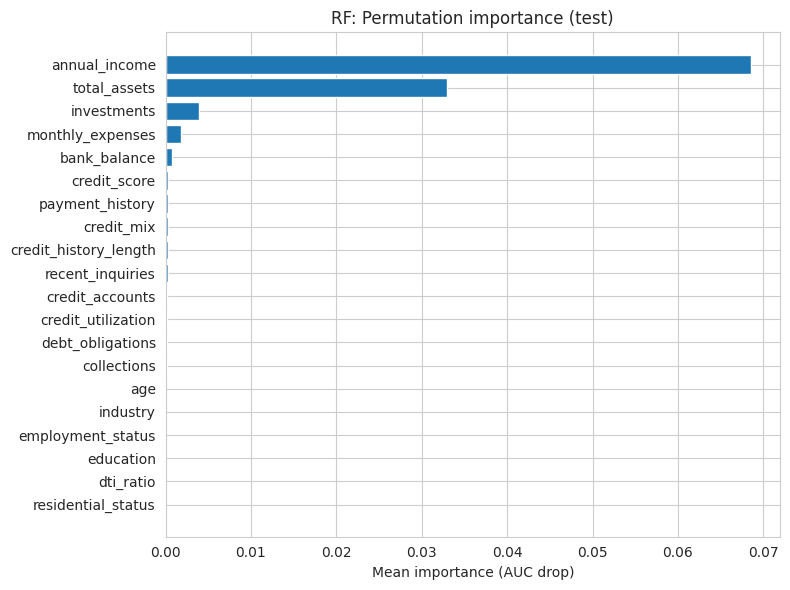

In [21]:
# CELDA 13
# =========================
# (GRÁFICOS) Random Forest
# =========================
rf_best = rf_gs.best_estimator_

plot_cv_score_curve(
    rf_gs,
    param_name="model__n_estimators",
    x_label="n_estimators",
    title="RF: AUC en CV vs n_estimators"
)

plot_cv_score_curve(
    rf_gs,
    param_name="model__min_samples_split",
    x_label="min_samples_split",
    title="RF: AUC en CV vs min_samples_split"
)

_ = plot_roc_curve_from_estimator(rf_best, X_test, y_test, title="RF: ROC (test)")
_ = plot_pr_curve_from_estimator(rf_best, X_test, y_test, title="RF: Precision-Recall (test)")
plot_confusion_matrix_from_estimator(rf_best, X_test, y_test, threshold=0.5, title="RF: Matriz de Confusión")

# Feature importance nativa del RF
prep_rf = rf_best.named_steps["prep"]
model_rf = rf_best.named_steps["model"]
plot_feature_importance_rf(model_rf, prep_rf, top=25, title="RF: Feature importance (nativa)")

# Extra "tipo clase": permutation importance
plot_permutation_importance(rf_best, X_test, y_test, prep_rf, top=20, title="RF: Permutation importance (test)")

,Modelo,AUC_test,Accuracy_test,F1_test
1,Lasso,0.999968,0.995,0.995015
0,Ridge,0.999916,0.993,0.993021
3,RandomForest,0.997456,0.970,0.969758
2,Bagging,0.996676,0.973,0.972919


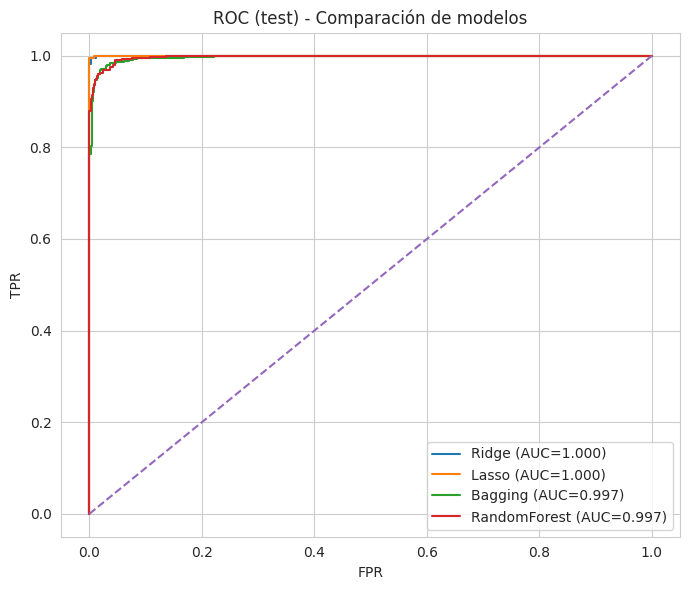

In [14]:
# CELDA 14
# =========================
# Comparación final (tabla + ROC superpuesto tipo clase)
# =========================
models = {
    "Ridge": ridge_best,
    "Lasso": lasso_best,
    "Bagging": bag_best,
    "RandomForest": rf_best
}

rows = []
for name, est in models.items():
    proba = est.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    rows.append({
        "Modelo": name,
        "AUC_test": roc_auc_score(y_test, proba),
        "Accuracy_test": accuracy_score(y_test, pred),
        "F1_test": f1_score(y_test, pred)
    })

res = pd.DataFrame(rows).sort_values("AUC_test", ascending=False)
display(res)

# ROC superpuesto
plt.figure(figsize=(7,6))
for name, est in models.items():
    proba = est.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC (test) - Comparación de modelos")
plt.legend()
plt.tight_layout()
plt.show()